<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/DeepLearning/BasicsofTensor(Torch%26Keras).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
if torch.backends.mps.is_available():
  device = torch.device("mps")
elif torch.cuda.is_available():
  device = torch.device("cuda")
else:
 device = torch.device("cpu")
device

device(type='cuda')

#Numpy vs torch

In [2]:
##Creating an array in numpy

In [3]:
import numpy as np
np.array([1,2,3])

array([1, 2, 3])

##Creating a tensor in torch

In [4]:
a = torch.tensor([1,2,3])
a

tensor([1, 2, 3])

In [5]:
type(a)

torch.Tensor

##Creating a randomly initialized array in numpy


In [6]:
rand_a = np.random.randn(2,3)#2 rows, 3 column
rand_a

array([[ 0.07973408,  0.43123901, -0.91545314],
       [-0.0482727 , -0.20087389, -0.13756623]])

##Creating a randomly initialized tensor in torch



In [7]:
rand_b = torch.randn(2,3)#2 rows, 3 column
rand_b

tensor([[-0.6248, -1.2493,  0.7620],
        [-0.0115,  0.1243, -1.0222]])

In [8]:
np.random.randn(3)#1D aray of size 3

array([-0.15649455, -2.07853089, -0.49725349])

#Gradient

In [9]:
x = torch.tensor(5.0, requires_grad= True)
x

tensor(5., requires_grad=True)

In [10]:
y = (x -3)** 2
y

tensor(4., grad_fn=<PowBackward0>)

In [11]:
y.backward()

In [12]:
y.item()

4.0

In [13]:
y.grad

/tmp/ipykernel_1211/486760323.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  y.grad


In [14]:
x.grad

tensor(4.)

x is origional tensor. y is function of x. When y.grad() is done, x tensor stores the derivative not y. Is it correct? Yes. letensor is a tensor you directly create (not a result of an operation). PyTorch only saves gradients for leaf tensors by default to save memory, since in neural networks you only need gradients for the parameters (weights), not every intermediate computation.

## For a tensor of values 5, and loss function (x-3)**2. Code to find optimal value of x for which loss is minimum. we can for x = 3 loss will be zero.

In [15]:
x = torch.tensor(5.0, requires_grad=True)
for i in range(20):
  #calcuate loss
  loss = (x-3)**2
  loss.backward()
  #update x
  with torch.no_grad(): #disables gradient tracking during the update (we don't want PyTorch to track this operation)
    x.sub_(0.1 * x.grad) # Perform in-place update
  print(x)
  x.grad.zero_()#Resets gradient to 0 before the next iteration. This is critical — PyTorch accumulates gradients by default, so without this, x.grad would keep adding up across iterations.

tensor(4.6000, requires_grad=True)
tensor(4.2800, requires_grad=True)
tensor(4.0240, requires_grad=True)
tensor(3.8192, requires_grad=True)
tensor(3.6554, requires_grad=True)
tensor(3.5243, requires_grad=True)
tensor(3.4194, requires_grad=True)
tensor(3.3355, requires_grad=True)
tensor(3.2684, requires_grad=True)
tensor(3.2147, requires_grad=True)
tensor(3.1718, requires_grad=True)
tensor(3.1374, requires_grad=True)
tensor(3.1100, requires_grad=True)
tensor(3.0880, requires_grad=True)
tensor(3.0704, requires_grad=True)
tensor(3.0563, requires_grad=True)
tensor(3.0450, requires_grad=True)
tensor(3.0360, requires_grad=True)
tensor(3.0288, requires_grad=True)
tensor(3.0231, requires_grad=True)


In [16]:
loss.item() #Value of loss after 20 iteration

0.0008307595271617174

In [17]:
loss


tensor(0.0008, grad_fn=<PowBackward0>)

In [18]:
x.grad.item()

0.0

In [19]:
torch.__version__

'2.10.0+cu128'

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time

In [21]:
# Download and load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),           # Convert image to tensor (also scales to 0-1)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 503kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]


In [22]:
train_dataset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

In [23]:
type(train_dataset)

torchvision.datasets.mnist.MNIST

In [24]:
len(train_dataset)

60000

In [25]:
len(test_dataset)

10000

In [26]:
train_dataset[59999][0].shape#image shape. Each image has 28 pixel in rows and 28 pixels vertically

torch.Size([1, 28, 28])

In [27]:
image, label = train_dataset[0]  # get first sample

print(image.shape)   # torch.Size([1, 28, 28])
#                                  ^  ^   ^
#                               channel height width

print(label)         # e.g. 5  (the digit in the image)
print(image.min())   # tensor(0.)  — pixel min
print(image.max())   # tensor(1.)  — pixel max (scaled by ToTensor)

torch.Size([1, 28, 28])
5
tensor(0.)
tensor(1.)


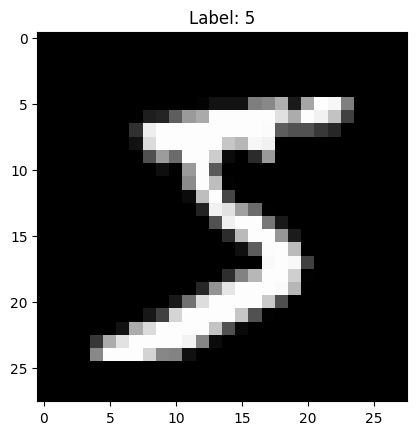

In [28]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap='gray')
# squeeze() removes the channel dim: [1,28,28] → [28,28]
plt.title(f"Label: {label}")
plt.show()

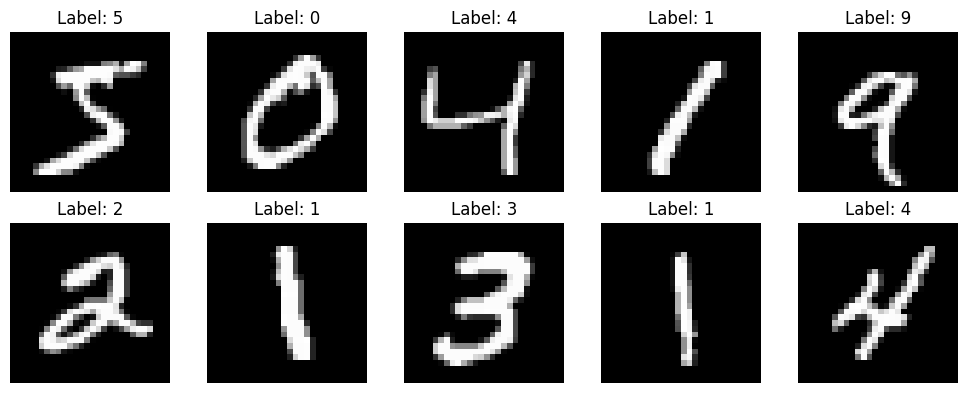

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

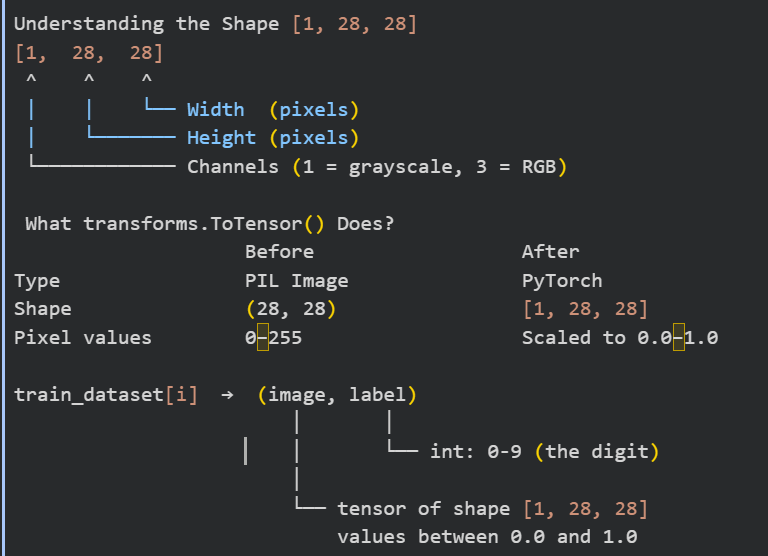

In [30]:
import collections

labels = [label for _, label in train_dataset]
counter = collections.Counter(labels)
print(counter)

Counter({1: 6742, 7: 6265, 3: 6131, 2: 5958, 9: 5949, 0: 5923, 6: 5918, 8: 5851, 4: 5842, 5: 5421})


Why normalize?

Neural networks train faster and more stably with small values
Keeps all inputs in the same range
Prevents large pixel values from dominating gradients

Why flatten?

A basic neural network (fully connected) expects a 1D vector per sample, not a 2D grid
Each pixel becomes an individual input feature

In [31]:
model_network = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

In [32]:
model_network

Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): ReLU()
  (6): Linear(in_features=64, out_features=10, bias=True)
)

In [33]:
# 1. Define Hyperparameters
batch_size = 256
learning_rate = 0.001
epochs = 10

# 2. Create DataLoaders
# The DataLoader will handle batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 3. Instantiate the model, loss function, and optimizer
# model_network is already defined in a previous cell
model_network.to(device) # Move model to the detected device (CPU/GPU/MPS)

loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss is suitable for multi-class classification
optimizer = torch.optim.Adam(model_network.parameters(), lr=learning_rate) # Adam optimizer

# 4. Training Loop
print("Starting training...")
for epoch in range(epochs):
    model_network.train() # Set the model to training mode
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        # Flatten the 28x28 images to a 784-dimensional vector
        data = data.view(data.size(0), -1).to(device) # Move data to device
        target = target.to(device) # Move target to device

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        output = model_network(data)

        # Calculate loss
        loss = loss_fn(output, target)

        # Backward pass (compute gradients)
        loss.backward()

        # Update model parameters
        optimizer.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 100 == 0: # Print every 100 batches
            print(f'Epoch [{epoch+1}/{epochs}], Step [{batch_idx+1}/{len(train_loader)}], Loss: {running_loss/100:.4f}')
            running_loss = 0.0

    # 5. Evaluation after each epoch (optional)
    model_network.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation during evaluation
        for data, target in test_loader:
            data = data.view(data.size(0), -1).to(device)
            target = target.to(device)
            output = model_network(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = 100 * correct / total
    print(f'Epoch [{epoch+1}/{epochs}], Test Accuracy: {accuracy:.2f}%')

print("Training complete!")


Starting training...
Epoch [1/10], Step [100/235], Loss: 0.8276
Epoch [1/10], Step [200/235], Loss: 0.3020
Epoch [1/10], Test Accuracy: 93.36%
Epoch [2/10], Step [100/235], Loss: 0.2139
Epoch [2/10], Step [200/235], Loss: 0.1726
Epoch [2/10], Test Accuracy: 95.64%
Epoch [3/10], Step [100/235], Loss: 0.1322
Epoch [3/10], Step [200/235], Loss: 0.1233
Epoch [3/10], Test Accuracy: 96.66%
Epoch [4/10], Step [100/235], Loss: 0.0950
Epoch [4/10], Step [200/235], Loss: 0.0976
Epoch [4/10], Test Accuracy: 96.69%
Epoch [5/10], Step [100/235], Loss: 0.0726
Epoch [5/10], Step [200/235], Loss: 0.0747
Epoch [5/10], Test Accuracy: 96.96%
Epoch [6/10], Step [100/235], Loss: 0.0592
Epoch [6/10], Step [200/235], Loss: 0.0566
Epoch [6/10], Test Accuracy: 97.52%
Epoch [7/10], Step [100/235], Loss: 0.0472
Epoch [7/10], Step [200/235], Loss: 0.0468
Epoch [7/10], Test Accuracy: 97.68%
Epoch [8/10], Step [100/235], Loss: 0.0343
Epoch [8/10], Step [200/235], Loss: 0.0402
Epoch [8/10], Test Accuracy: 97.65%
Epo

In [34]:
model_network.eval() # Set the model to evaluation mode

# Initialize dictionaries to store correct predictions and total predictions per class
correct_per_label = {i: 0 for i in range(10)}
total_per_label = {i: 0 for i in range(10)}

with torch.no_grad(): # Disable gradient calculation during evaluation
    for data, target in test_loader:
        data = data.view(data.size(0), -1).to(device) # Flatten and move data to device
        target = target.to(device) # Move target to device
        output = model_network(data)
        _, predicted = torch.max(output.data, 1)

        # Iterate through each sample in the batch
        for label, prediction in zip(target, predicted):
            label_item = label.item()
            total_per_label[label_item] += 1
            if prediction.item() == label_item:
                correct_per_label[label_item] += 1

print("\nAccuracy per label:")
for i in range(10):
    accuracy = 100 * correct_per_label[i] / total_per_label[i] if total_per_label[i] > 0 else 0
    print(f'Label {i}: {accuracy:.2f}% ({correct_per_label[i]}/{total_per_label[i]})')



Accuracy per label:
Label 0: 98.27% (963/980)
Label 1: 98.94% (1123/1135)
Label 2: 98.06% (1012/1032)
Label 3: 99.11% (1001/1010)
Label 4: 98.27% (965/982)
Label 5: 95.63% (853/892)
Label 6: 98.75% (946/958)
Label 7: 97.57% (1003/1028)
Label 8: 96.61% (941/974)
Label 9: 97.72% (986/1009)


In [35]:
# How keras abstracts lot of these details for you.

In [36]:
import tensorflow as tf
import numpy as np

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
# constant and a variable.

# Stage 1: Represent Data

In [38]:
# From a Python list — the simplest case
pixel_brightness = tf.constant(0.75)

type(pixel_brightness)

tensorflow.python.framework.ops.EagerTensor

In [39]:
exam_scores = tf.constant([82, 91, 76, 88])   # vector
print("Vector:", exam_scores)

Vector: tf.Tensor([82 91 76 88], shape=(4,), dtype=int32)


In [40]:
grayscale_image = np.random.rand(28, 28).astype(np.float32)
image_tensor = tf.constant(grayscale_image)
print("Image tensor shape:", image_tensor.shape)

Image tensor shape: (28, 28)


In [41]:
# Bias vector: start at zero (common default)
bias = tf.zeros([128])
print("Bias shape:", bias.shape)

# Weight matrix: random initialisation (we'll discuss *why* random later)
weights = tf.random.normal([784, 128])   # 784 inputs → 128 neurons
print("Weight matrix shape:", weights.shape)

Bias shape: (128,)
Weight matrix shape: (784, 128)


# Stage 2: Inspecting Data

In [42]:
sample_np = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32)

print(f"Shape : {sample_np.shape}")   # (2, 3) — 2 rows, 3 columns
print(f"Rank  : {sample_np.ndim}")    # 2 dimensions
print(f"Size  : {sample_np.size}")    # 6 total elements
print(f"Dtype : {sample_np.dtype}")   # float32 — the default for neural nets

Shape : (2, 3)
Rank  : 2
Size  : 6
Dtype : float32


In [43]:
sample_np = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.float32)

print(f"Shape : {sample_np.shape}")   # (2, 3) — 2 rows, 3 columns
print(f"Rank  : {sample_np.ndim}")    # 2 dimensions
print(f"Size  : {sample_np.size}")    # 6 total elements
print(f"Dtype : {sample_np.dtype}")   # float32 — the default for neural nets

Shape : (3, 3)
Rank  : 2
Size  : 9
Dtype : float32


In [44]:
sample = tf.constant([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=tf.float32)

print(f"Shape : {sample.shape}")        # (2, 3) — 2 rows, 3 columns
print(f"Rank  : {tf.rank(sample).numpy()}")  # 2 dimensions
print(f"Size  : {tf.size(sample).numpy()}")  # 6 total elements
print(f"Dtype : {sample.dtype}")         # float32 — the default for neural nets

Shape : (3, 3)
Rank  : 2
Size  : 9
Dtype : <dtype: 'float32'>


In [45]:
tf.rank(sample).numpy()

np.int32(2)

In [46]:
# Scenario 1: Flatten an image for a fully-connected layer
image = tf.random.normal([28, 28])        # one grayscale image
flat  = tf.reshape(image, [-1])            # -1 means "figure it out" → (784,)
print(f"Image {image.shape} → Flat {flat.shape}")

Image (28, 28) → Flat (784,)


In [47]:
# Scenario 2: Add a batch dimension (model expects batch × features)
single_sample = tf.constant([1.0, 2.0, 3.0])          # shape (3,)
batched       = tf.expand_dims(single_sample, axis=0)  # shape (1, 3)
print(f"Single sample {single_sample.shape} → Batched {batched.shape}")

Single sample (3,) → Batched (1, 3)


In [48]:
# Scenario 3: Remove an unnecessary batch dim after prediction
prediction = tf.constant([[[0.1, 0.9]]])   # shape (1, 1, 2) — extra dims
clean      = tf.squeeze(prediction)         # shape (2,)
print(f"Prediction {prediction.shape} → Squeezed {clean.shape}")

Prediction (1, 1, 2) → Squeezed (2,)


In [49]:
# Data arrives as (3 features, 5 samples) — wrong orientation
data = tf.random.normal([3, 5])
print("Original:", data.shape)      # (3, 5)

# Network expects (samples, features)
data_t = tf.transpose(data)
print("Transposed:", data_t.shape)  # (5, 3) ✓

Original: (3, 5)
Transposed: (5, 3)


In [50]:
# Simulating: you have one image, model expects a batch
single_image = tf.random.normal([224, 224, 3])
print("Single image:", single_image.shape)

image_batch = tf.expand_dims(single_image, axis=0)
print("Batch of 1 :", image_batch.shape)   # (1, 224, 224, 3) — ready for model.predict()

Single image: (224, 224, 3)
Batch of 1 : (1, 224, 224, 3)


In [51]:
# Class labels as integers
labels = tf.constant([0, 2, 1, 0, 2])

# One-hot encode (depth = number of classes)
one_hot_labels = tf.one_hot(labels, depth=3)
print("Labels:", labels.numpy())
print("One-hot:\n", one_hot_labels.numpy())

Labels: [0 2 1 0 2]
One-hot:
 [[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


if you can think about it, there exists a way to do it.

In [52]:
# Simulating one layer: 4 samples, 3 features each
X = tf.constant([[1, 2, 3],
                 [4, 5, 6],
                 [7, 8, 9],
                 [10, 11, 12]], dtype=tf.float32)  # shape (4, 3)


# Weight matrix: 3 input features → 2 neurons
W = tf.constant([[0.1, 0.2],
                 [0.3, 0.4],
                 [0.5, 0.6]], dtype=tf.float32)     # shape (3, 2)

# Bias: one per output neuron
b = tf.constant([0.01, 0.02], dtype=tf.float32)     # shape (2,)


# Forward pass through one layer
z = tf.matmul(X, W) + b    # matrix multiply + broadcast add
print("Layer output shape:", z.shape)  # (4, 2) — 4 samples, 2 neurons
print("Layer output:\n", z.numpy())

Layer output shape: (4, 2)
Layer output:
 [[ 2.21       2.8200002]
 [ 4.9100003  6.42     ]
 [ 7.6100006 10.02     ]
 [10.31      13.620001 ]]


In [53]:
a = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)
b = tf.constant([[5, 6], [7, 8]], dtype=tf.float32)

print("Addition (a + b):\n", (a + b).numpy())
print("Element-wise multiply (a * b):\n", (a * b).numpy())
print("Matrix multiply (a @ b):\n", tf.matmul(a, b).numpy())
# Note the difference: * is element-wise, @ is proper matrix multiplication

Addition (a + b):
 [[ 6.  8.]
 [10. 12.]]
Element-wise multiply (a * b):
 [[ 5. 12.]
 [21. 32.]]
Matrix multiply (a @ b):
 [[19. 22.]
 [43. 50.]]


In [54]:
# Model outputs (raw scores for 3 classes, 4 samples)
logits = tf.constant([
    [2.0, 1.0, 0.1],
    [0.5, 2.5, 0.3],
    [1.2, 0.3, 3.1],
    [0.1, 0.2, 2.8]
], dtype=tf.float32)

# Which class does the model predict for each sample?
predictions = tf.argmax(logits, axis=1)
print("Predicted classes:", predictions.numpy())  # [0, 1, 2, 2]

# What's the confidence (max score) for each?
confidence = tf.reduce_max(logits, axis=1)
print("Confidence scores:", confidence.numpy())


# Average score across all samples and classes
print("Mean logit:", tf.reduce_mean(logits).numpy())

# Sum along columns (per-class totals) and rows (per-sample totals)
print("Sum per class:", tf.reduce_sum(logits, axis=0).numpy())
print("Sum per sample:", tf.reduce_sum(logits, axis=1).numpy())

Predicted classes: [0 1 2 2]
Confidence scores: [2.  2.5 3.1 2.8]
Mean logit: 1.1750001
Sum per class: [3.8 4.  6.3]
Sum per sample: [3.1 3.3 4.6 3.1]


# Variables and Constants

In [55]:
# Constants: your data and learning rate don't change during a training step
learning_rate = tf.constant(0.01)
x_input = tf.constant([1.0, 2.0, 3.0])

# Variables: weights and biases DO change
weight = tf.Variable([0.5, -0.3, 0.8])
bias   = tf.Variable(0.0)

print("Before update — weight:", weight.numpy(), "bias:", bias.numpy())

# Simulate one gradient descent step
# (In practice, TensorFlow computes gradients automatically — we'll see that soon)
fake_gradient_w = tf.constant([0.1, -0.2, 0.05])
fake_gradient_b = tf.constant(0.03)

weight.assign(weight - learning_rate * fake_gradient_w)
bias.assign(bias - learning_rate * fake_gradient_b)

print("After update  — weight:", weight.numpy(), "bias:", bias.numpy())

Before update — weight: [ 0.5 -0.3  0.8] bias: 0.0
After update  — weight: [ 0.499  -0.298   0.7995] bias: -0.00029999999


In [56]:
# You CANNOT do this with a constant:
c = tf.constant([1.0, 2.0])
try:
    c.assign([3.0, 4.0])
except AttributeError as e:
    print(f"Expected error: {e}")
# This is by design — input data shouldn't accidentally get modified.

Expected error: 'tensorflow.python.framework.ops.EagerTensor' object has no attribute 'assign'


In [57]:
with tf.device('/CPU:0'):
    import time

    # A function that simulates work (repeated sqrt — just to measure speed)
    def eager_fn(x):
        for _ in range(10000):
            x = tf.math.sqrt(x)
        return x

    @tf.function
    def graph_fn(x):
        for _ in range(10000):
            x = tf.math.sqrt(x)
        return x

    x = tf.random.uniform([500, 500])

    # Warm-up (first call compiles the graph — don't count it)
    _ = graph_fn(x)

    # Time eager mode
    start = time.time()
    eager_fn(x)
    eager_time = time.time() - start

    # Time graph mode
    start = time.time()
    graph_fn(x)
    graph_time = time.time() - start

    print(f"Eager mode : {eager_time:.4f}s")
    print(f"Graph mode : {graph_time:.4f}s")
    print(f"Speedup    : {eager_time / graph_time:.1f}x")

Eager mode : 2.3001s
Graph mode : 0.6254s
Speedup    : 3.7x


In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# 2. Preprocess the data
# Reshape and normalize images
image_size = 28 * 28
X_train = X_train.reshape(-1, image_size).astype('float32') / 255.0
X_test = X_test.reshape(-1, image_size).astype('float32') / 255.0

# One-hot encode labels
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# 3. Define the Keras model (similar architecture to the PyTorch model)
keras_model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(image_size,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Softmax for multi-class classification
])

# 4. Compile the model
keras_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
print("Keras Model Summary:")
keras_model.summary()

# 5. Train the model
print("\nStarting Keras training...")
batch_size = 256 # Keeping the same batch size as PyTorch example
epochs = 10 # Keeping the same number of epochs

history = keras_model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1, # Show progress bar
    validation_data=(X_test, y_test)
)

print("\nKeras Training Complete!")

# 6. Evaluate the model
loss, accuracy = keras_model.evaluate(X_test, y_test, verbose=0)
print(f'\nKeras Test Loss: {loss:.4f}')
print(f'Keras Test Accuracy: {accuracy*100:.2f}%')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)


Starting Keras training...
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9003 - loss: 0.3466 - val_accuracy: 0.9560 - val_loss: 0.1482
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9631 - loss: 0.1255 - val_accuracy: 0.9633 - val_loss: 0.1166
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9738 - loss: 0.0858 - val_accuracy: 0.9754 - val_loss: 0.0770
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9805 - loss: 0.0620 - val_accuracy: 0.9761 - val_loss: 0.0741
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9857 - loss: 0.0467 - val_accuracy: 0.9757 - val_loss: 0.0822
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9881 - loss: 0.0374 - val_accuracy: 0.9769 - val_loss: 0.0699
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9910 - loss: 0.0281 - val_accuracy: 0.9789 - val_loss: 0.0711
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9933 - lo